# 02 — Fixed Train / Validation / Calibration Split

**Project:** Pedi-CGAM Lite  
**Dataset:** VinDr-PCXR  
**Platform:** Kaggle  
**Purpose:** Create the **permanent development split** used by every later experiment.

## Why this split needs special care

Stage 01 showed an extremely long-tailed diagnosis distribution. Several pathology classes have only a handful of positive images. A simple random split could easily place **zero rare positives** in validation, making rare-class model comparison impossible.

This notebook therefore uses a **rarity-aware search over multi-label stratified candidate splits**.

### Target split

- **Training:** ~70%
- **Validation:** ~15%
- **Calibration:** ~15%
- **Official test:** untouched and completely separate

### Important rules

1. Official test labels are **not loaded**.
2. The final chosen split is saved permanently.
3. Later notebooks must reuse these exact image IDs.
4. The notebook prioritizes:
   - keeping rare classes represented in training
   - putting at least one positive in validation whenever mathematically possible
   - balancing common disease prevalences
   - balancing sufficiently supported box-finding classes
5. Calibration does **not** need a positive example from every ultra-rare class because later calibration will use a global strategy rather than unstable per-class calibration for classes with only a few positives.

### Final Kaggle ZIP

`/kaggle/working/PediCGAM_Stage02_Fixed_Split_All_Outputs.zip`


In [1]:
# ============================================================
# 1. Install multi-label stratification package
# ============================================================
%pip install -q iterative-stratification

print("✅ iterative-stratification ready.")


Note: you may need to restart the kernel to use updated packages.
✅ iterative-stratification ready.


In [2]:
# ============================================================
# 2. Imports and reproducibility
# ============================================================
import os
import sys
import json
import math
import random
import hashlib
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_SEARCH_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working/PediCGAM/stage02_fixed_split")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
SPLIT_DIR = OUTPUT_DIR / "splits"

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Output directory:", OUTPUT_DIR)


Python: 3.12.13
Output directory: /kaggle/working/PediCGAM/stage02_fixed_split


## Operational definitions frozen from Stage 01

Stage 01 established:

- 15 image-level output columns
- 14 pathology labels + `No finding`
- 37 annotation class names
- 36 **box-supervised finding classes** after excluding `No finding`

For long-tail disease analysis, we use the **14 pathology labels**, not `No finding`.

For finding stratification support, we use **class names**, not `class_id`, because the dataset metadata contains a duplicated numeric class ID for different class names.


In [3]:
# ============================================================
# 3. Automatically locate VinDr-PCXR
# ============================================================
def find_vindr_root(search_root=DATA_SEARCH_ROOT):
    candidates = []
    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {p.name for p in folder.iterdir() if p.is_file()}
        score = sum(
            x in names
            for x in ["image_labels_train.csv", "annotations_train.csv"]
        )
        candidates.append((score, folder))
    candidates.sort(key=lambda x: (-x[0], len(str(x[1]))))
    return candidates

candidates = find_vindr_root()

if not candidates:
    raise FileNotFoundError("VinDr-PCXR not found under /kaggle/input.")

DATA_ROOT = candidates[0][1]

print("DATA_ROOT:", DATA_ROOT)


DATA_ROOT: /kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0


In [4]:
# ============================================================
# 4. Load OFFICIAL TRAINING metadata only
# ============================================================
# Intentionally do NOT load image_labels_test.csv or annotations_test.csv.

labels = pd.read_csv(DATA_ROOT / "image_labels_train.csv")
ann = pd.read_csv(DATA_ROOT / "annotations_train.csv")

print("image_labels_train:", labels.shape)
print("annotations_train :", ann.shape)

assert labels["image_id"].nunique() == 7728
assert ann["image_id"].nunique() == 7728

NON_LABEL_COLUMNS = ["image_id", "rad_ID"]
LABEL_COLUMNS = [c for c in labels.columns if c not in NON_LABEL_COLUMNS]

assert len(LABEL_COLUMNS) == 15
assert "No finding" in LABEL_COLUMNS

PATHOLOGY_COLUMNS = [c for c in LABEL_COLUMNS if c != "No finding"]

print("\n15 image-level outputs:")
print(LABEL_COLUMNS)

print("\n14 pathology labels:")
print(PATHOLOGY_COLUMNS)


image_labels_train: (7728, 17)
annotations_train : (10371, 8)

15 image-level outputs:
['No finding', 'Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor']

14 pathology labels:
['Bronchitis', 'Brocho-pneumonia', 'Other disease', 'Bronchiolitis', 'Situs inversus', 'Pneumonia', 'Pleuro-pneumonia', 'Diagphramatic hernia', 'Tuberculosis', 'Congenital emphysema', 'CPAM', 'Hyaline membrane disease', 'Mediastinal tumor', 'Lung tumor']


In [5]:
# ============================================================
# 5. Audit the 54 all-zero image-level target cases from Stage 01
# ============================================================
Y_all = labels[LABEL_COLUMNS].astype(int)

all_zero_mask = Y_all.sum(axis=1) == 0
all_zero_ids = labels.loc[all_zero_mask, "image_id"].tolist()

print("Images with all 15 image-level targets = 0:", len(all_zero_ids))

zero_ann = ann[ann["image_id"].isin(all_zero_ids)].copy()

zero_case_findings = (
    zero_ann["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="annotation_rows")
)

display(zero_case_findings)

pd.DataFrame({"image_id": all_zero_ids}).to_csv(
    TABLE_DIR / "all_zero_image_level_target_ids.csv",
    index=False
)

zero_case_findings.to_csv(
    TABLE_DIR / "all_zero_target_annotation_classes.csv",
    index=False
)

print(
    "\nThese cases are NOT automatically deleted. "
    "They remain valid training-set records unless a later evidence-based "
    "reason supports exclusion."
)


Images with all 15 image-level targets = 0: 54


,class_name,annotation_rows
0,Other lesion,29
1,Peribronchovascular interstitial opacity,24
2,Bronchial thickening,12
3,Cardiomegaly,2
4,Lung hyperinflation,2
5,Other opacity,1
6,Clavicle fracture,1
7,Consolidation,1
8,Reticulonodular opacity,1
9,Lung cyst,1



These cases are NOT automatically deleted. They remain valid training-set records unless a later evidence-based reason supports exclusion.


In [6]:
# ============================================================
# 6. Build one binary finding-presence vector per image
# ============================================================
# Use class_name rather than class_id.
# Exclude 'No finding' from local finding classes.

LOCAL_FINDING_NAMES = sorted(
    [x for x in ann["class_name"].dropna().unique().tolist()
     if x != "No finding"]
)

print("Local finding class names:", len(LOCAL_FINDING_NAMES))
assert len(LOCAL_FINDING_NAMES) == 36

finding_presence = (
    ann[ann["class_name"] != "No finding"]
    .assign(value=1)
    .pivot_table(
        index="image_id",
        columns="class_name",
        values="value",
        aggfunc="max",
        fill_value=0
    )
    .reindex(columns=LOCAL_FINDING_NAMES, fill_value=0)
)

finding_presence = (
    finding_presence
    .reindex(labels["image_id"], fill_value=0)
)
finding_presence.index = labels.index

finding_counts = finding_presence.sum(axis=0).astype(int).sort_values(
    ascending=False
)

finding_count_df = (
    finding_counts
    .rename("positive_images")
    .rename_axis("finding")
    .reset_index()
)

display(finding_count_df)
finding_count_df.to_csv(
    TABLE_DIR / "finding_presence_counts.csv",
    index=False
)


Local finding class names: 36


,finding,positive_images
0,Peribronchovascular interstitial opacity,1358
1,Bronchial thickening,562
2,Reticulonodular opacity,509
3,Consolidation,176
4,Cardiomegaly,161
5,Other opacity,148
6,Diffuse aveolar opacity,119
7,Lung hyperinflation,108
8,Other lesion,65
9,Enlarged PA,61


In [7]:
# ============================================================
# 7. Select supported findings to help stratification
# ============================================================
# Ultra-rare findings with only 1–9 images cannot be distributed
# stably across three subsets. We still keep them in the data,
# but they are not used as hard stratification targets.
#
# Findings with >=10 positive images are included in the
# candidate stratification matrix.

MIN_FINDING_SUPPORT_FOR_STRATIFICATION = 10

SUPPORTED_FINDINGS = finding_counts[
    finding_counts >= MIN_FINDING_SUPPORT_FOR_STRATIFICATION
].index.tolist()

print(
    "Supported finding labels used for split balancing:",
    len(SUPPORTED_FINDINGS)
)
print(SUPPORTED_FINDINGS)


Supported finding labels used for split balancing: 18
['Peribronchovascular interstitial opacity', 'Bronchial thickening', 'Reticulonodular opacity', 'Consolidation', 'Cardiomegaly', 'Other opacity', 'Diffuse aveolar opacity', 'Lung hyperinflation', 'Other lesion', 'Enlarged PA', 'Boot-shaped heart', 'Atelectasis', 'Dextro cardia', 'Pleural effusion', 'Interstitial lung disease - ILD', 'Egg on string sign', 'Infiltration', 'Other nodule/mass']


In [8]:
# ============================================================
# 8. Create combined stratification matrix
# ============================================================
# Main labels: all 15 image-level outputs
# Supporting labels: box/finding presence with >=10 images

disease_matrix = labels[LABEL_COLUMNS].astype(int).to_numpy()
finding_matrix = finding_presence[SUPPORTED_FINDINGS].astype(int).to_numpy()

Y_STRAT = np.concatenate(
    [disease_matrix, finding_matrix],
    axis=1
)

print("Stratification matrix shape:", Y_STRAT.shape)
print(
    f"= {len(LABEL_COLUMNS)} image-level labels + "
    f"{len(SUPPORTED_FINDINGS)} supported finding labels"
)


Stratification matrix shape: (7728, 33)
= 15 image-level labels + 18 supported finding labels


# Candidate split search

A single multi-label stratified split can still allocate ultra-rare classes poorly by chance.

We therefore generate many candidate splits and select the one with the best score.

## Rare-class priorities

For each pathology:

- **2 positives:** aim for at least 1 train + 1 validation
- **3–6 positives:** keep most in train and aim for at least 1 validation
- **7–9 positives:** require train + validation; calibration is desirable
- **10+ positives:** require positives in train, validation, and calibration

This is not data leakage. We are using only the official training metadata to create a reproducible development split.


In [9]:
# ============================================================
# 9. Helper functions for candidate generation and scoring
# ============================================================
N = len(labels)
X_dummy = np.zeros((N, 1), dtype=np.float32)

def make_candidate_split(random_state):
    # First: 70% train, 30% temporary
    outer = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=0.30,
        random_state=random_state
    )

    train_idx, temp_idx = next(
        outer.split(X_dummy, Y_STRAT)
    )

    # Second: split temporary set into 15% validation + 15% calibration
    inner = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=0.50,
        random_state=random_state + 100000
    )

    X_temp = np.zeros((len(temp_idx), 1), dtype=np.float32)
    Y_temp = Y_STRAT[temp_idx]

    val_local, cal_local = next(
        inner.split(X_temp, Y_temp)
    )

    val_idx = temp_idx[val_local]
    cal_idx = temp_idx[cal_local]

    return (
        np.sort(train_idx),
        np.sort(val_idx),
        np.sort(cal_idx)
    )

pathology_total_counts = labels[PATHOLOGY_COLUMNS].sum(axis=0).astype(int)

def subset_counts(indices, columns):
    return labels.iloc[indices][columns].sum(axis=0).astype(int)

def candidate_score(train_idx, val_idx, cal_idx):
    score = 0.0
    details = []

    train_counts = subset_counts(train_idx, PATHOLOGY_COLUMNS)
    val_counts = subset_counts(val_idx, PATHOLOGY_COLUMNS)
    cal_counts = subset_counts(cal_idx, PATHOLOGY_COLUMNS)

    # -------- Rare pathology allocation penalties --------
    for cls in PATHOLOGY_COLUMNS:
        total = int(pathology_total_counts[cls])
        tr = int(train_counts[cls])
        va = int(val_counts[cls])
        ca = int(cal_counts[cls])

        # Every learnable pathology must retain training positives.
        if tr == 0:
            score += 1_000_000

        # Keep at least roughly half of ultra-rare positives in training.
        min_train = max(1, math.ceil(total * 0.50))
        if tr < min_train:
            score += 100_000 * (min_train - tr)

        # Validation presence is critical for model comparison whenever
        # total positives >= 2.
        if total >= 2 and va == 0:
            score += 250_000

        # Calibration presence is required only for adequately supported classes.
        if total >= 10 and ca == 0:
            score += 100_000

        # For moderate/common classes, encourage approximate proportions.
        expected = np.array([0.70, 0.15, 0.15]) * total
        actual = np.array([tr, va, ca], dtype=float)

        if total >= 10:
            score += float(np.abs(actual - expected).sum()) * 100

        details.append((cls, total, tr, va, ca))

    # -------- Global image-level prevalence balance --------
    overall_prev = labels[LABEL_COLUMNS].mean(axis=0)

    for idx in [train_idx, val_idx, cal_idx]:
        split_prev = labels.iloc[idx][LABEL_COLUMNS].mean(axis=0)
        score += float(np.abs(split_prev - overall_prev).mean()) * 50_000

    # -------- Supported finding balance --------
    if SUPPORTED_FINDINGS:
        overall_fprev = finding_presence[SUPPORTED_FINDINGS].mean(axis=0)

        for idx in [train_idx, val_idx, cal_idx]:
            split_prev = finding_presence.iloc[idx][SUPPORTED_FINDINGS].mean(axis=0)
            score += float(
                np.abs(split_prev - overall_fprev).mean()
            ) * 20_000

    return score, details


In [10]:
# ============================================================
# 10. Search many reproducible candidate splits
# ============================================================
N_CANDIDATES = 500

records = []
best = None

for random_state in tqdm(
    range(SEED, SEED + N_CANDIDATES),
    desc="Searching candidate splits"
):
    train_idx, val_idx, cal_idx = make_candidate_split(random_state)
    score, details = candidate_score(train_idx, val_idx, cal_idx)

    rec = {
        "random_state": random_state,
        "score": score,
        "train_size": len(train_idx),
        "validation_size": len(val_idx),
        "calibration_size": len(cal_idx),
    }
    records.append(rec)

    if best is None or score < best["score"]:
        best = {
            "random_state": random_state,
            "score": score,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "cal_idx": cal_idx,
            "details": details,
        }

candidate_df = pd.DataFrame(records).sort_values("score")
display(candidate_df.head(20))

candidate_df.to_csv(
    TABLE_DIR / "candidate_split_search_scores.csv",
    index=False
)

print("\nSelected random_state:", best["random_state"])
print("Selected score:", best["score"])
print(
    "Sizes:",
    len(best["train_idx"]),
    len(best["val_idx"]),
    len(best["cal_idx"])
)


Searching candidate splits:   0%|          | 0/500 [00:00<?, ?it/s]

,random_state,score,train_size,validation_size,calibration_size
263,305,787.596230,5408,1159,1161
54,96,788.145224,5406,1161,1161
443,485,802.872398,5416,1156,1156
19,61,812.145308,5398,1162,1168
116,158,817.374933,5406,1167,1155
476,518,250783.431558,5406,1160,1162
425,467,250784.036078,5410,1159,1159
244,286,250784.077821,5406,1162,1160
23,65,250784.692979,5410,1159,1159
152,194,250785.089435,5410,1159,1159



Selected random_state: 305
Selected score: 787.5962297722073
Sizes: 5408 1159 1161


In [11]:
# ============================================================
# 11. Build the final split manifest
# ============================================================
train_idx = best["train_idx"]
val_idx = best["val_idx"]
cal_idx = best["cal_idx"]

split_labels = np.empty(N, dtype=object)
split_labels[train_idx] = "train"
split_labels[val_idx] = "validation"
split_labels[cal_idx] = "calibration"

manifest = labels[
    ["image_id", "rad_ID"] + LABEL_COLUMNS
].copy()

manifest.insert(2, "split", split_labels)

assert manifest["split"].notna().all()
assert manifest["image_id"].nunique() == len(manifest)

display(manifest.head())

manifest.to_csv(
    SPLIT_DIR / "fixed_split_manifest_with_labels.csv",
    index=False
)

# Minimal manifest for later data loaders
manifest[["image_id", "split"]].to_csv(
    SPLIT_DIR / "fixed_split_manifest.csv",
    index=False
)

for split_name in ["train", "validation", "calibration"]:
    manifest.loc[
        manifest["split"] == split_name,
        ["image_id"]
    ].to_csv(
        SPLIT_DIR / f"{split_name}_image_ids.csv",
        index=False
    )


,image_id,rad_ID,split,No finding,Bronchitis,Brocho-pneumonia,Other disease,Bronchiolitis,Situs inversus,Pneumonia,Pleuro-pneumonia,Diagphramatic hernia,Tuberculosis,Congenital emphysema,CPAM,Hyaline membrane disease,Mediastinal tumor,Lung tumor
0,6cb53aff85c71b98ad13d67a131708c6,R3,validation,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,40414c05687cdb156823c156967b13f0,R3,train,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0e4a464dfbf8abc6333c82f1b77b6455,R3,calibration,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,f4d3fab0b71381e6b237dc36301e85a0,R3,train,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,b58c9b1c89978a0b1f8533b7a2ca1088,R3,train,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# ============================================================
# 12. Verify split sizes and zero overlap
# ============================================================
train_ids = set(manifest.loc[manifest["split"] == "train", "image_id"])
val_ids = set(manifest.loc[manifest["split"] == "validation", "image_id"])
cal_ids = set(manifest.loc[manifest["split"] == "calibration", "image_id"])

overlap_train_val = len(train_ids & val_ids)
overlap_train_cal = len(train_ids & cal_ids)
overlap_val_cal = len(val_ids & cal_ids)

size_df = (
    manifest["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="images")
)

size_df["percent"] = size_df["images"] / len(manifest) * 100

display(size_df)

overlap_df = pd.DataFrame([
    {"pair":"train-validation", "overlap":overlap_train_val},
    {"pair":"train-calibration", "overlap":overlap_train_cal},
    {"pair":"validation-calibration", "overlap":overlap_val_cal},
])

display(overlap_df)

size_df.to_csv(TABLE_DIR / "split_sizes.csv", index=False)
overlap_df.to_csv(TABLE_DIR / "split_overlap_check.csv", index=False)

assert overlap_train_val == 0
assert overlap_train_cal == 0
assert overlap_val_cal == 0
assert len(train_ids | val_ids | cal_ids) == 7728


,split,images,percent
0,train,5408,69.979296
1,calibration,1161,15.023292
2,validation,1159,14.997412


,pair,overlap
0,train-validation,0
1,train-calibration,0
2,validation-calibration,0


In [13]:
# ============================================================
# 13. Disease/pathology positive counts by split
# ============================================================
disease_split_rows = []

for cls in LABEL_COLUMNS:
    total = int(labels[cls].sum())

    row = {
        "label": cls,
        "total_positive": total,
        "overall_prevalence_percent": total / N * 100,
    }

    for split_name in ["train", "validation", "calibration"]:
        sub = manifest[manifest["split"] == split_name]
        pos = int(sub[cls].sum())

        row[f"{split_name}_positive"] = pos
        row[f"{split_name}_prevalence_percent"] = (
            pos / len(sub) * 100
        )

    disease_split_rows.append(row)

disease_split_df = pd.DataFrame(disease_split_rows)

display(disease_split_df)
disease_split_df.to_csv(
    TABLE_DIR / "disease_distribution_by_split.csv",
    index=False
)


,label,total_positive,overall_prevalence_percent,train_positive,train_prevalence_percent,validation_positive,validation_prevalence_percent,calibration_positive,calibration_prevalence_percent
0,No finding,5143,66.550207,3600,66.568047,772,66.609146,771,66.408269
1,Bronchitis,842,10.895445,589,10.891272,127,10.957722,126,10.852713
2,Brocho-pneumonia,545,7.052277,381,7.045118,82,7.075065,82,7.062877
3,Other disease,412,5.331263,288,5.325444,62,5.349439,62,5.340224
4,Bronchiolitis,497,6.431159,348,6.434911,75,6.471096,74,6.373816
5,Situs inversus,11,0.142340,8,0.147929,1,0.086281,2,0.172265
6,Pneumonia,392,5.072464,274,5.066568,59,5.090595,59,5.081826
7,Pleuro-pneumonia,6,0.077640,4,0.073964,1,0.086281,1,0.086133
8,Diagphramatic hernia,3,0.038820,2,0.036982,1,0.086281,0,0.000000
9,Tuberculosis,14,0.181159,10,0.184911,2,0.172563,2,0.172265


In [14]:
# ============================================================
# 14. Rare pathology allocation report
# ============================================================
rare_rows = []

for cls in PATHOLOGY_COLUMNS:
    total = int(labels[cls].sum())
    tr = int(
        manifest.loc[manifest["split"] == "train", cls].sum()
    )
    va = int(
        manifest.loc[manifest["split"] == "validation", cls].sum()
    )
    ca = int(
        manifest.loc[manifest["split"] == "calibration", cls].sum()
    )

    if total >= 2:
        validation_goal = va >= 1
    else:
        validation_goal = True

    if total >= 10:
        calibration_goal = ca >= 1
    else:
        calibration_goal = True

    min_train = max(1, math.ceil(total * 0.50))
    training_goal = tr >= min_train

    rare_rows.append({
        "pathology": cls,
        "total": total,
        "train": tr,
        "validation": va,
        "calibration": ca,
        "min_train_goal": min_train,
        "training_goal_met": training_goal,
        "validation_positive_goal_met": validation_goal,
        "calibration_goal_met_if_required": calibration_goal,
    })

rare_allocation_df = pd.DataFrame(rare_rows).sort_values(
    "total",
    ascending=True
)

display(rare_allocation_df)

rare_allocation_df.to_csv(
    TABLE_DIR / "pathology_rare_allocation_report.csv",
    index=False
)


,pathology,total,train,validation,calibration,min_train_goal,training_goal_met,validation_positive_goal_met,calibration_goal_met_if_required
9,Congenital emphysema,2,1,1,0,1,True,True,True
7,Diagphramatic hernia,3,2,1,0,2,True,True,True
10,CPAM,5,3,1,1,3,True,True,True
13,Lung tumor,5,3,1,1,3,True,True,True
6,Pleuro-pneumonia,6,4,1,1,3,True,True,True
12,Mediastinal tumor,8,6,1,1,4,True,True,True
4,Situs inversus,11,8,1,2,6,True,True,True
8,Tuberculosis,14,10,2,2,7,True,True,True
11,Hyaline membrane disease,19,13,3,3,10,True,True,True
5,Pneumonia,392,274,59,59,196,True,True,True


In [15]:
# ============================================================
# 15. Pathology evaluability flags for later validation metrics
# ============================================================
evaluable_rows = []

for _, row in rare_allocation_df.iterrows():
    val_pos = int(row["validation"])
    total = int(row["total"])

    evaluable_rows.append({
        "pathology": row["pathology"],
        "total_positive": total,
        "validation_positive": val_pos,
        "validation_has_positive": val_pos > 0,
        "validation_metric_stability_note": (
            "very unstable (1 positive)"
            if val_pos == 1 else
            "unstable (2-4 positives)"
            if 2 <= val_pos <= 4 else
            "more usable"
            if val_pos >= 5 else
            "AUPRC undefined without positives"
        )
    })

evaluable_df = pd.DataFrame(evaluable_rows)
display(evaluable_df)

evaluable_df.to_csv(
    TABLE_DIR / "validation_pathology_evaluability.csv",
    index=False
)

print(
    "\nImportant: even when a rare class has one validation positive, "
    "its per-class metric is statistically unstable. "
    "Later model selection will therefore use overall macro-AUPRC plus "
    "rare-group summaries and per-class reporting, not a single ultra-rare "
    "class score by itself."
)


,pathology,total_positive,validation_positive,validation_has_positive,validation_metric_stability_note
0,Congenital emphysema,2,1,True,very unstable (1 positive)
1,Diagphramatic hernia,3,1,True,very unstable (1 positive)
2,CPAM,5,1,True,very unstable (1 positive)
3,Lung tumor,5,1,True,very unstable (1 positive)
4,Pleuro-pneumonia,6,1,True,very unstable (1 positive)
5,Mediastinal tumor,8,1,True,very unstable (1 positive)
6,Situs inversus,11,1,True,very unstable (1 positive)
7,Tuberculosis,14,2,True,unstable (2-4 positives)
8,Hyaline membrane disease,19,3,True,unstable (2-4 positives)
9,Pneumonia,392,59,True,more usable



Important: even when a rare class has one validation positive, its per-class metric is statistically unstable. Later model selection will therefore use overall macro-AUPRC plus rare-group summaries and per-class reporting, not a single ultra-rare class score by itself.


In [16]:
# ============================================================
# 16. Finding distribution by split
# ============================================================
finding_manifest = finding_presence.copy()
finding_manifest.insert(0, "split", split_labels)
finding_manifest.insert(0, "image_id", labels["image_id"].values)

finding_rows = []

for finding in LOCAL_FINDING_NAMES:
    total = int(finding_presence[finding].sum())

    row = {
        "finding": finding,
        "total_positive_images": total,
    }

    for split_name in ["train", "validation", "calibration"]:
        mask = split_labels == split_name
        pos = int(finding_presence.loc[mask, finding].sum())

        row[f"{split_name}_positive_images"] = pos

    finding_rows.append(row)

finding_split_df = pd.DataFrame(finding_rows).sort_values(
    "total_positive_images",
    ascending=False
)

display(finding_split_df)

finding_split_df.to_csv(
    TABLE_DIR / "finding_distribution_by_split.csv",
    index=False
)


,finding,total_positive_images,train_positive_images,validation_positive_images,calibration_positive_images
29,Peribronchovascular interstitial opacity,1358,952,203,203
5,Bronchial thickening,562,393,84,85
34,Reticulonodular opacity,509,356,76,77
10,Consolidation,176,123,27,26
7,Cardiomegaly,161,113,24,24
27,Other opacity,148,104,22,22
12,Diffuse aveolar opacity,119,83,18,18
23,Lung hyperinflation,108,76,16,16
25,Other lesion,65,45,10,10
16,Enlarged PA,61,43,9,9


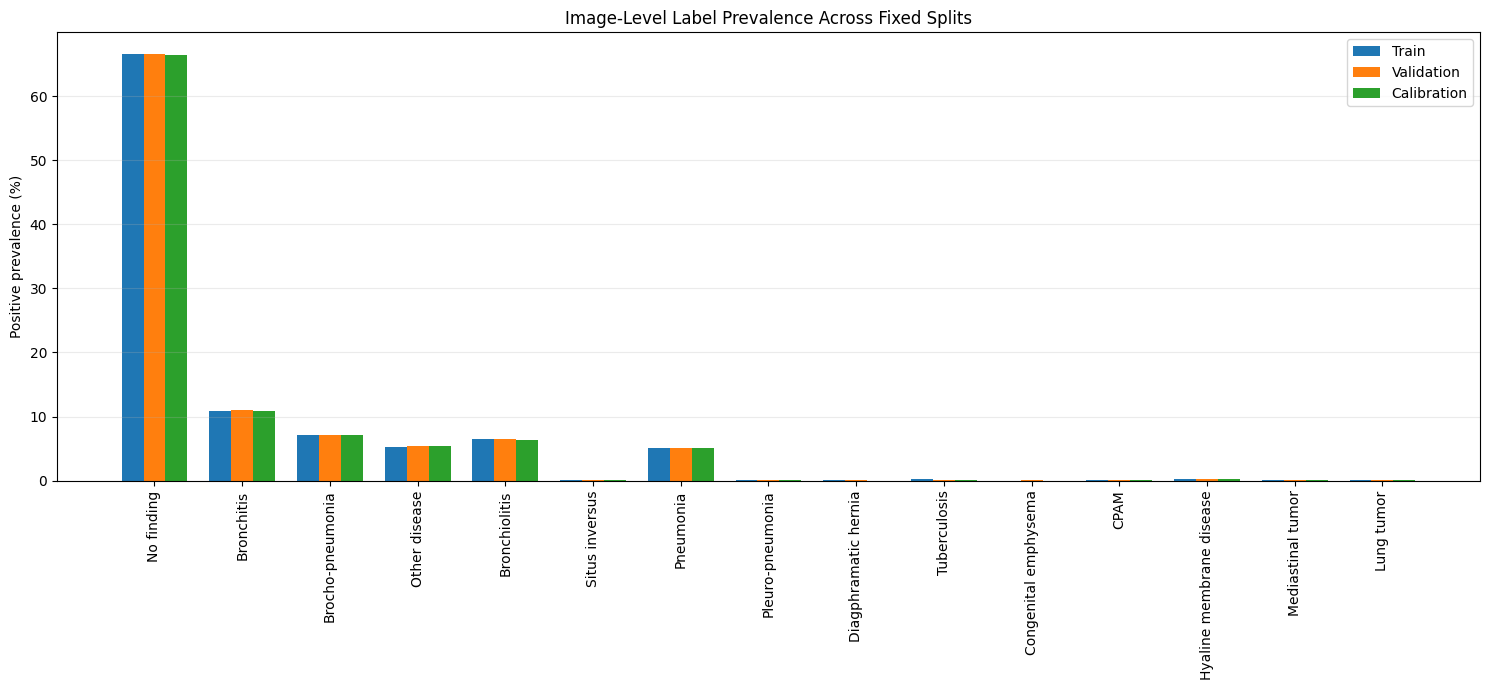

Saved: /kaggle/working/PediCGAM/stage02_fixed_split/figures/01_disease_prevalence_by_split.png


In [17]:
# ============================================================
# 17. Plot disease prevalence by split
# ============================================================
plot_labels = LABEL_COLUMNS

x = np.arange(len(plot_labels))
width = 0.25

overall = labels[plot_labels].mean(axis=0).values * 100
train_prev = (
    manifest[manifest["split"] == "train"][plot_labels]
    .mean(axis=0).values * 100
)
val_prev = (
    manifest[manifest["split"] == "validation"][plot_labels]
    .mean(axis=0).values * 100
)
cal_prev = (
    manifest[manifest["split"] == "calibration"][plot_labels]
    .mean(axis=0).values * 100
)

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(x - width, train_prev, width, label="Train")
ax.bar(x, val_prev, width, label="Validation")
ax.bar(x + width, cal_prev, width, label="Calibration")

ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=90)
ax.set_ylabel("Positive prevalence (%)")
ax.set_title("Image-Level Label Prevalence Across Fixed Splits")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "01_disease_prevalence_by_split.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


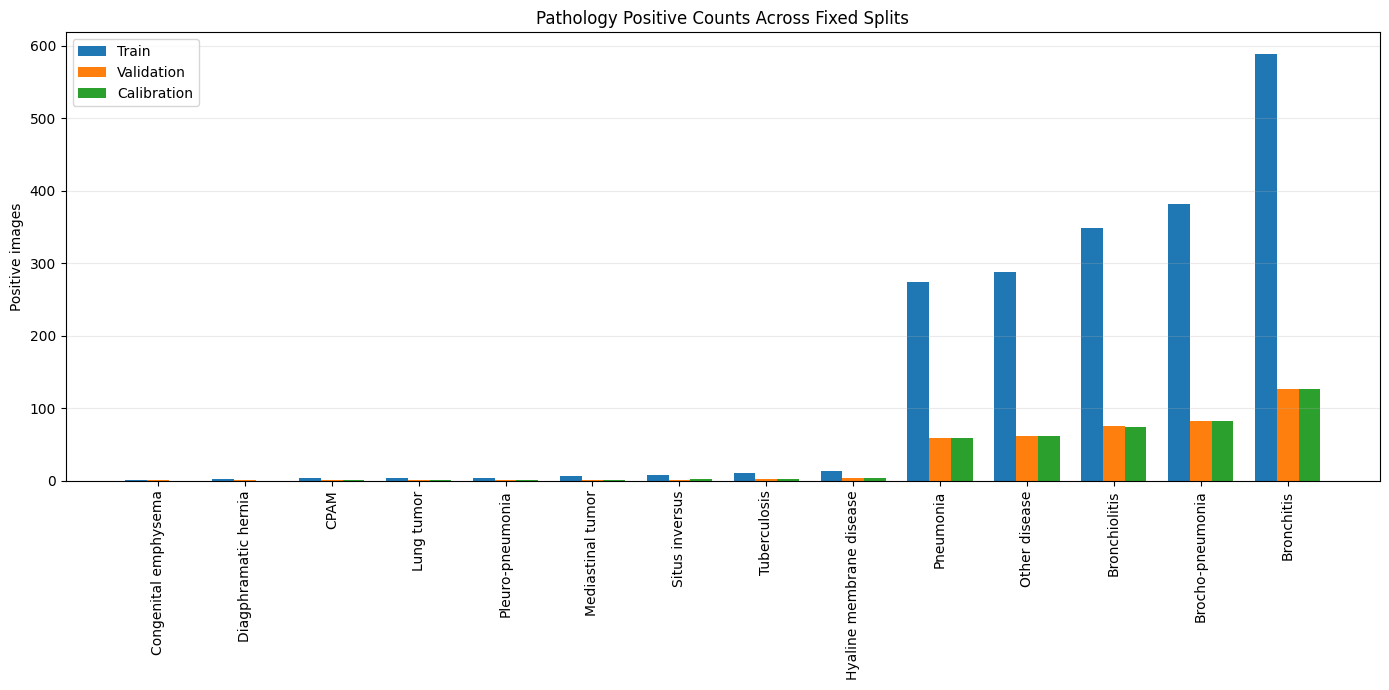

Saved: /kaggle/working/PediCGAM/stage02_fixed_split/figures/02_pathology_positive_counts_by_split.png


In [18]:
# ============================================================
# 18. Plot rare pathology positive counts by split
# ============================================================
rare_plot = rare_allocation_df.sort_values("total")

x = np.arange(len(rare_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x - width,
    rare_plot["train"],
    width,
    label="Train"
)
ax.bar(
    x,
    rare_plot["validation"],
    width,
    label="Validation"
)
ax.bar(
    x + width,
    rare_plot["calibration"],
    width,
    label="Calibration"
)

ax.set_xticks(x)
ax.set_xticklabels(rare_plot["pathology"], rotation=90)
ax.set_ylabel("Positive images")
ax.set_title("Pathology Positive Counts Across Fixed Splits")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
path = FIG_DIR / "02_pathology_positive_counts_by_split.png"
plt.savefig(path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", path)


In [19]:
# ============================================================
# 19. Recreate pathology head / middle / tail groups and save them
# ============================================================
pathology_frequency = pd.DataFrame({
    "label": PATHOLOGY_COLUMNS,
    "positive_images": [
        int(labels[c].sum())
        for c in PATHOLOGY_COLUMNS
    ]
}).sort_values(
    "positive_images",
    ascending=False
).reset_index(drop=True)

# Same Stage 01 equal-as-possible grouping:
# 14 pathologies -> Head 5, Middle 5, Tail 4
n = len(pathology_frequency)
base = n // 3
rem = n % 3
sizes = [base + (1 if i < rem else 0) for i in range(3)]

group_names = (
    ["Head"] * sizes[0] +
    ["Middle"] * sizes[1] +
    ["Tail"] * sizes[2]
)

pathology_frequency["frequency_rank"] = np.arange(1, n + 1)
pathology_frequency["rarity_group"] = group_names[:n]

display(pathology_frequency)

pathology_frequency.to_csv(
    TABLE_DIR / "frozen_pathology_head_middle_tail_groups.csv",
    index=False
)


,label,positive_images,frequency_rank,rarity_group
0,Bronchitis,842,1,Head
1,Brocho-pneumonia,545,2,Head
2,Bronchiolitis,497,3,Head
3,Other disease,412,4,Head
4,Pneumonia,392,5,Head
5,Hyaline membrane disease,19,6,Middle
6,Tuberculosis,14,7,Middle
7,Situs inversus,11,8,Middle
8,Mediastinal tumor,8,9,Middle
9,Pleuro-pneumonia,6,10,Middle


In [20]:
# ============================================================
# 20. Save exact local-finding class list
# ============================================================
finding_class_table = pd.DataFrame({
    "finding_index": np.arange(len(LOCAL_FINDING_NAMES)),
    "class_name": LOCAL_FINDING_NAMES,
    "positive_images": [
        int(finding_presence[c].sum())
        for c in LOCAL_FINDING_NAMES
    ]
})

finding_class_table["supported_for_split_balancing"] = (
    finding_class_table["positive_images"]
    >= MIN_FINDING_SUPPORT_FOR_STRATIFICATION
)

display(finding_class_table)

finding_class_table.to_csv(
    TABLE_DIR / "frozen_36_local_finding_classes.csv",
    index=False
)


,finding_index,class_name,positive_images,supported_for_split_balancing
0,0,Anterior mediastinal mass,5,False
1,1,Aortic enlargement,2,False
2,2,Atelectasis,23,True
3,3,Boot-shaped heart,35,True
4,4,Bronchectasis,3,False
5,5,Bronchial thickening,562,True
6,6,Calcification,1,False
7,7,Cardiomegaly,161,True
8,8,Chest wall mass,3,False
9,9,Clavicle fracture,5,False


In [21]:
# ============================================================
# 21. Create reproducibility hashes
# ============================================================
def sha256_text(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def hash_id_set(ids):
    return sha256_text(
        "\n".join(sorted(map(str, ids)))
    )

hashes = {
    "train_image_ids_sha256": hash_id_set(train_ids),
    "validation_image_ids_sha256": hash_id_set(val_ids),
    "calibration_image_ids_sha256": hash_id_set(cal_ids),
}

minimal_manifest_path = SPLIT_DIR / "fixed_split_manifest.csv"

with open(minimal_manifest_path, "rb") as f:
    hashes["fixed_split_manifest_file_sha256"] = hashlib.sha256(
        f.read()
    ).hexdigest()

hash_df = pd.DataFrame(
    [{"item": k, "sha256": v} for k, v in hashes.items()]
)

display(hash_df)

hash_df.to_csv(
    TABLE_DIR / "split_reproducibility_hashes.csv",
    index=False
)


,item,sha256
0,train_image_ids_sha256,a21b4dd2e864ea8fee867f4bd4d299bbb7acb262b8416d...
1,validation_image_ids_sha256,c9e80c4e21c648ad02f96aa0a7617683590f7d15673e4c...
2,calibration_image_ids_sha256,c49798735ef72b7ba28ca8595b77b0faf5661d8c7e2d32...
3,fixed_split_manifest_file_sha256,3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8c...


In [22]:
# ============================================================
# 22. Create split metadata / decision record
# ============================================================
split_metadata = {
    "stage": "02_Fixed_Train_Validation_Calibration_Split",
    "dataset": "VinDr-PCXR",
    "official_training_images": 7728,
    "official_test_labels_used": False,
    "target_ratios": {
        "train": 0.70,
        "validation": 0.15,
        "calibration": 0.15,
    },
    "selected_candidate_random_state": int(best["random_state"]),
    "candidate_search_count": N_CANDIDATES,
    "stratification_method": "MultilabelStratifiedShuffleSplit",
    "stratification_image_level_labels": LABEL_COLUMNS,
    "stratification_supported_finding_count": len(SUPPORTED_FINDINGS),
    "minimum_finding_support_for_stratification": (
        MIN_FINDING_SUPPORT_FOR_STRATIFICATION
    ),
    "split_sizes": {
        "train": len(train_ids),
        "validation": len(val_ids),
        "calibration": len(cal_ids),
    },
    "hashes": hashes,
    "policy_notes": [
        "Official test labels are sealed.",
        "No finding is retained as an image-level output but excluded from pathology rarity groups.",
        "Local finding classes use class_name, not class_id.",
        "Ultra-rare classes are prioritized for training and validation representation.",
        "Calibration positivity is not required for every ultra-rare class.",
        "Later experiments must reuse this exact split manifest."
    ],
}

with open(OUTPUT_DIR / "stage02_split_metadata.json", "w") as f:
    json.dump(split_metadata, f, indent=2)

print(json.dumps(split_metadata, indent=2))


{
  "stage": "02_Fixed_Train_Validation_Calibration_Split",
  "dataset": "VinDr-PCXR",
  "official_training_images": 7728,
  "official_test_labels_used": false,
  "target_ratios": {
    "train": 0.7,
    "validation": 0.15,
    "calibration": 0.15
  },
  "selected_candidate_random_state": 305,
  "candidate_search_count": 500,
  "stratification_method": "MultilabelStratifiedShuffleSplit",
  "stratification_image_level_labels": [
    "No finding",
    "Bronchitis",
    "Brocho-pneumonia",
    "Other disease",
    "Bronchiolitis",
    "Situs inversus",
    "Pneumonia",
    "Pleuro-pneumonia",
    "Diagphramatic hernia",
    "Tuberculosis",
    "Congenital emphysema",
    "CPAM",
    "Hyaline membrane disease",
    "Mediastinal tumor",
    "Lung tumor"
  ],
  "stratification_supported_finding_count": 18,
  "minimum_finding_support_for_stratification": 10,
  "split_sizes": {
    "train": 5408,
    "validation": 1159,
    "calibration": 1161
  },
  "hashes": {
    "train_image_ids_sha256": "

In [23]:
# ============================================================
# 23. Final PASS / REVIEW gate
# ============================================================
rare_train_ok = bool(
    rare_allocation_df["training_goal_met"].all()
)

rare_val_ok = bool(
    rare_allocation_df["validation_positive_goal_met"].all()
)

required_cal_ok = bool(
    rare_allocation_df[
        "calibration_goal_met_if_required"
    ].all()
)

checks = pd.DataFrame([
    {
        "check": "All 7,728 images assigned exactly once",
        "passed": (
            len(train_ids | val_ids | cal_ids) == 7728
            and overlap_train_val == 0
            and overlap_train_cal == 0
            and overlap_val_cal == 0
        )
    },
    {
        "check": "Train size approximately 70%",
        "passed": abs(len(train_ids) / N - 0.70) < 0.01
    },
    {
        "check": "Validation size approximately 15%",
        "passed": abs(len(val_ids) / N - 0.15) < 0.01
    },
    {
        "check": "Calibration size approximately 15%",
        "passed": abs(len(cal_ids) / N - 0.15) < 0.01
    },
    {
        "check": "Rare-pathology training allocation goals met",
        "passed": rare_train_ok
    },
    {
        "check": "Every pathology with >=2 positives has >=1 validation positive",
        "passed": rare_val_ok
    },
    {
        "check": "Calibration presence goals met for pathologies with >=10 positives",
        "passed": required_cal_ok
    },
])

checks["status"] = checks["passed"].map(
    {True: "PASS", False: "REVIEW"}
)

display(checks)

checks.to_csv(
    OUTPUT_DIR / "stage02_final_status.csv",
    index=False
)

FINAL_STATUS = "PASS" if checks["passed"].all() else "REVIEW"

print("\n" + "=" * 75)
print("FINAL STAGE 02 STATUS:", FINAL_STATUS)

if FINAL_STATUS == "PASS":
    print("✅ FIXED SPLIT IS READY TO FREEZE")
    print(
        "Next: baseline model notebooks must use "
        "splits/fixed_split_manifest.csv exactly."
    )
else:
    print(
        "⚠️ Do not begin baseline training yet. "
        "Send the output back for review."
    )

print("=" * 75)


,check,passed,status
0,"All 7,728 images assigned exactly once",True,PASS
1,Train size approximately 70%,True,PASS
2,Validation size approximately 15%,True,PASS
3,Calibration size approximately 15%,True,PASS
4,Rare-pathology training allocation goals met,True,PASS
5,Every pathology with >=2 positives has >=1 val...,True,PASS
6,Calibration presence goals met for pathologies...,True,PASS



FINAL STAGE 02 STATUS: PASS
✅ FIXED SPLIT IS READY TO FREEZE
Next: baseline model notebooks must use splits/fixed_split_manifest.csv exactly.


In [24]:
# ============================================================
# 24. Create easy-to-read Stage 02 summary
# ============================================================
summary_lines = [
    "Pedi-CGAM Lite — Stage 02 Fixed Split Summary",
    "=" * 55,
    "",
    f"Final status: {FINAL_STATUS}",
    f"Selected candidate random state: {best['random_state']}",
    "",
    f"Train images: {len(train_ids)} ({len(train_ids)/N*100:.2f}%)",
    f"Validation images: {len(val_ids)} ({len(val_ids)/N*100:.2f}%)",
    f"Calibration images: {len(cal_ids)} ({len(cal_ids)/N*100:.2f}%)",
    "",
    "Official test labels used: NO",
    "",
    "IMPORTANT:",
    "- This split is permanent if FINAL STATUS = PASS.",
    "- All later experiments must reuse fixed_split_manifest.csv.",
    "- 14 pathology labels are used for head/middle/tail analysis.",
    "- 'No finding' remains a model output but is not a pathology rarity class.",
    "- 36 local finding classes are frozen by class_name.",
    "",
    "Ultra-rare validation allocation:"
]

for _, r in rare_allocation_df.sort_values("total").iterrows():
    if int(r["total"]) <= 19:
        summary_lines.append(
            f"- {r['pathology']}: total={int(r['total'])}, "
            f"train={int(r['train'])}, val={int(r['validation'])}, "
            f"cal={int(r['calibration'])}"
        )

summary_text = "\n".join(summary_lines)

print(summary_text)

with open(OUTPUT_DIR / "README_STAGE02_RESULTS.txt", "w") as f:
    f.write(summary_text)


Pedi-CGAM Lite — Stage 02 Fixed Split Summary

Final status: PASS
Selected candidate random state: 305

Train images: 5408 (69.98%)
Validation images: 1159 (15.00%)
Calibration images: 1161 (15.02%)

Official test labels used: NO

IMPORTANT:
- This split is permanent if FINAL STATUS = PASS.
- All later experiments must reuse fixed_split_manifest.csv.
- 14 pathology labels are used for head/middle/tail analysis.
- 'No finding' remains a model output but is not a pathology rarity class.
- 36 local finding classes are frozen by class_name.

Ultra-rare validation allocation:
- Congenital emphysema: total=2, train=1, val=1, cal=0
- Diagphramatic hernia: total=3, train=2, val=1, cal=0
- CPAM: total=5, train=3, val=1, cal=1
- Lung tumor: total=5, train=3, val=1, cal=1
- Pleuro-pneumonia: total=6, train=4, val=1, cal=1
- Mediastinal tumor: total=8, train=6, val=1, cal=1
- Situs inversus: total=11, train=8, val=1, cal=2
- Tuberculosis: total=14, train=10, val=2, cal=2
- Hyaline membrane disease

In [25]:
# ============================================================
# 25. List generated outputs
# ============================================================
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            f"{p.relative_to(OUTPUT_DIR)} "
            f"| {p.stat().st_size/(1024**2):.3f} MB"
        )


README_STAGE02_RESULTS.txt | 0.001 MB
figures/01_disease_prevalence_by_split.png | 0.144 MB
figures/02_pathology_positive_counts_by_split.png | 0.139 MB
splits/calibration_image_ids.csv | 0.037 MB
splits/fixed_split_manifest.csv | 0.300 MB
splits/fixed_split_manifest_with_labels.csv | 0.764 MB
splits/train_image_ids.csv | 0.170 MB
splits/validation_image_ids.csv | 0.036 MB
stage02_final_status.csv | 0.000 MB
stage02_split_metadata.json | 0.002 MB
tables/all_zero_image_level_target_ids.csv | 0.002 MB
tables/all_zero_target_annotation_classes.csv | 0.000 MB
tables/candidate_split_search_scores.csv | 0.018 MB
tables/disease_distribution_by_split.csv | 0.002 MB
tables/finding_distribution_by_split.csv | 0.001 MB
tables/finding_presence_counts.csv | 0.001 MB
tables/frozen_36_local_finding_classes.csv | 0.001 MB
tables/frozen_pathology_head_middle_tail_groups.csv | 0.000 MB
tables/pathology_rare_allocation_report.csv | 0.001 MB
tables/split_overlap_check.csv | 0.000 MB
tables/split_reproduci

# Final one-click Kaggle export

The final cell packages every Stage 02 output into:

`PediCGAM_Stage02_Fixed_Split_All_Outputs.zip`

If the final status is **PASS**, keep this ZIP safely. The split manifest inside it becomes a permanent input for all later model notebooks.


In [26]:
# ============================================================
# 26. ZIP ALL STAGE 02 OUTPUTS
# ============================================================
ZIP_BASE = Path(
    "/kaggle/working/PediCGAM_Stage02_Fixed_Split_All_Outputs"
)
ZIP_FILE = Path(str(ZIP_BASE) + ".zip")

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(OUTPUT_DIR)
)

print("✅ STAGE 02 ZIP CREATED")
print("File:", ZIP_FILE)
print(
    f"Size: {ZIP_FILE.stat().st_size/(1024**2):.2f} MB"
)
print("\nDownload this one ZIP from Kaggle Output.")


✅ STAGE 02 ZIP CREATED
File: /kaggle/working/PediCGAM_Stage02_Fixed_Split_All_Outputs.zip
Size: 0.69 MB

Download this one ZIP from Kaggle Output.


## What to send back

After running Stage 02, send either the executed notebook or the Kaggle ZIP.

The most important outputs are:

- `README_STAGE02_RESULTS.txt`
- `stage02_final_status.csv`
- `stage02_split_metadata.json`
- `tables/pathology_rare_allocation_report.csv`
- `tables/disease_distribution_by_split.csv`
- `tables/finding_distribution_by_split.csv`
- `splits/fixed_split_manifest.csv`

If the final status is **PASS**, the next notebooks will be the separate baseline experiments:

- `03A_Baseline_ResNet50.ipynb`
- `03B_Baseline_DenseNet121.ipynb`
- `03C_Baseline_EfficientNetB0.ipynb`
- `03D_Baseline_ConvNeXtTiny.ipynb`
